# Example 10: Surface Rover Navigation with IMU, LCRNS, and DEM Aiding

A lunar-surface rover near the south pole fuses a full strapdown **IMU** (accelerometer + gyroscope, Kalibr noise model), **LCRNS / LANS pseudoranges** from a five-satellite relay constellation (its own `LunarNavConstellation` agent, which the rover resolves and queries each epoch), and a **LOLA-DEM altitude constraint**, estimating the IMU biases online. This example is built on LuPNT's **agent-based simulation architecture**:

- a **`World`** — the shared, read-only environment (frame `MOON_PA`, point-mass Moon gravity, and the LOLA DEM site, loaded/cached from NASA PGDA).
- a thin **`Rover`** agent hosting a **`SurfaceRoverNavApp`** (an error-state strapdown-INS EKF). The app precomputes the driving-arc truth trajectory and synthesizes the IMU / pseudorange / DEM-constraint measurements each epoch from the `World`, then runs the predict/update cycle.

The whole scenario is described in one file, `configs/surface_rover_nav.yaml`. The ~30-min INS arc is compute-heavy, so we run it **once, in a standalone script**, and cache the results as CSV; this notebook just reads those CSVs and plots.

> **Run the simulation first** (from the repo root):
> ```bash
> python python/examples/ex10_run_surface_nav.py
> ```
> This writes CSVs to `output/python_examples/ex10_data/` (a full-sensor run and a DEM-constraint-disabled ablation). Re-run it whenever you change `configs/surface_rover_nav.yaml`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def zoom_ylim(ax, *series, frac=0.4, pad=1.4):
    """Set a symmetric y-limit to the post-convergence range (last 1-frac of the run) of the
    given series, so the plot illustrates the converged behavior rather than the large initial
    transient."""
    h = int(len(series[0]) * frac)
    m = max(float(np.nanmax(np.abs(np.asarray(s)[h:]))) for s in series)
    if m > 0:
        ax.set_ylim(-pad * m, pad * m)

# Locate the CSVs written by ex10_run_surface_nav.py (output/python_examples/ex10_data/).
DATA = None
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "output/python_examples/ex10_data/meta.json").exists():
        DATA = _b / "output/python_examples/ex10_data"
        break
    if (_b / "ex10_data/meta.json").exists():
        DATA = _b / "ex10_data"
        break
assert DATA is not None, "Run `python python/examples/ex10_run_surface_nav.py` first to generate ex10_data/."

meta = json.load(open(DATA / "meta.json"))
on = pd.read_csv(DATA / "series_dem_on.csv")    # DEM constraint enabled
off = pd.read_csv(DATA / "series_dem_off.csv")   # DEM constraint disabled (ablation)
dem_x = np.load(DATA / "dem_x.npy")
dem_y = np.load(DATA / "dem_y.npy")
dem_z = np.load(DATA / "dem_elevation.npy")

t_min = on["t_s"].values / 60.0
print(f"Site: {meta['site_id']} ({meta['site_name']})  epochs={len(on)}  dt={meta['dt_s']} s")
print(f"final 3D position error: DEM on {meta['final_pos_err_norm_dem_on']:.2f} m, "
      f"DEM off {meta['final_pos_err_norm_dem_off']:.2f} m")

Site: Site01 (Connecting ridge)  epochs=2401  dt=1.0 s
final 3D position error: DEM on 6.06 m, DEM off 16.65 m


## 1. Terrain and the rover ground track

The rover drives a slowly-curving arc over the DEM; its Up coordinate follows the terrain. Truth vs. the estimated track (DEM-aided).

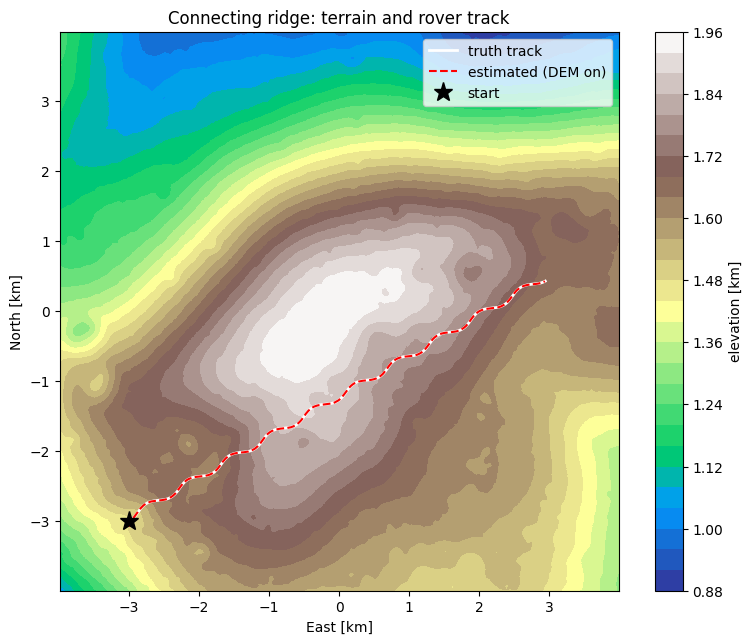

In [2]:
# DEM native coords -> local East/North about the tile center (km).
cx, cy = dem_x.mean(), dem_y.mean()
Xc = (dem_x - cx) / 1e3
Yc = (dem_y - cy) / 1e3

fig, ax = plt.subplots(figsize=(8, 6.5))
cf = ax.contourf(Xc, Yc, dem_z / 1e3, levels=30, cmap="terrain")
plt.colorbar(cf, ax=ax, label="elevation [km]")
ax.plot(on["track_truth_e"] / 1e3, on["track_truth_n"] / 1e3, "w-", lw=2, label="truth track")
ax.plot(on["track_est_e"] / 1e3, on["track_est_n"] / 1e3, "r--", lw=1.5, label="estimated (DEM on)")
ax.plot(on["track_truth_e"].iloc[0] / 1e3, on["track_truth_n"].iloc[0] / 1e3, "k*", ms=14, label="start")
ax.set_xlabel("East [km]"); ax.set_ylabel("North [km]")
ax.set_title(f"{meta['site_name']}: terrain and rover track")
ax.set_aspect("equal"); ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

## 2. Position error vs. filter 3σ (East / North / Up)

The estimate error (truth − estimate) stays inside the filter's ±3σ envelope in all three local axes — the filter is consistent.

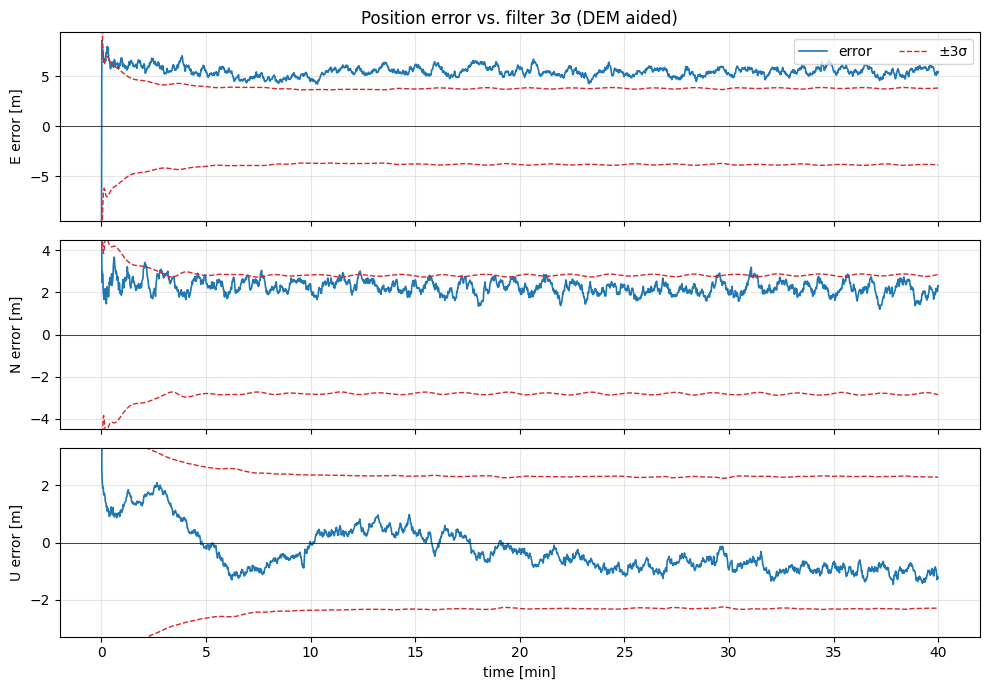

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
comps = [("E", "pos_err_x", "pos_sigma_x"), ("N", "pos_err_y", "pos_sigma_y"),
         ("U", "pos_err_z", "pos_sigma_z")]
for ax, (lbl, ec, sc) in zip(axes, comps):
    ax.plot(t_min, on[ec], "C0", lw=1.2, label="error")
    ax.plot(t_min, 3 * on[sc], "C3--", lw=1, label="±3σ")
    ax.plot(t_min, -3 * on[sc], "C3--", lw=1)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel(f"{lbl} error [m]"); ax.grid(alpha=0.3)
    zoom_ylim(ax, on[ec], 3 * on[sc])
axes[0].legend(loc="upper right", ncol=2)
axes[-1].set_xlabel("time [min]")
axes[0].set_title("Position error vs. filter 3σ (DEM aided)")
plt.tight_layout(); plt.show()

## 3. IMU bias estimation

The accelerometer and gyroscope biases are estimated online; the error converges toward zero within the filter 3σ.

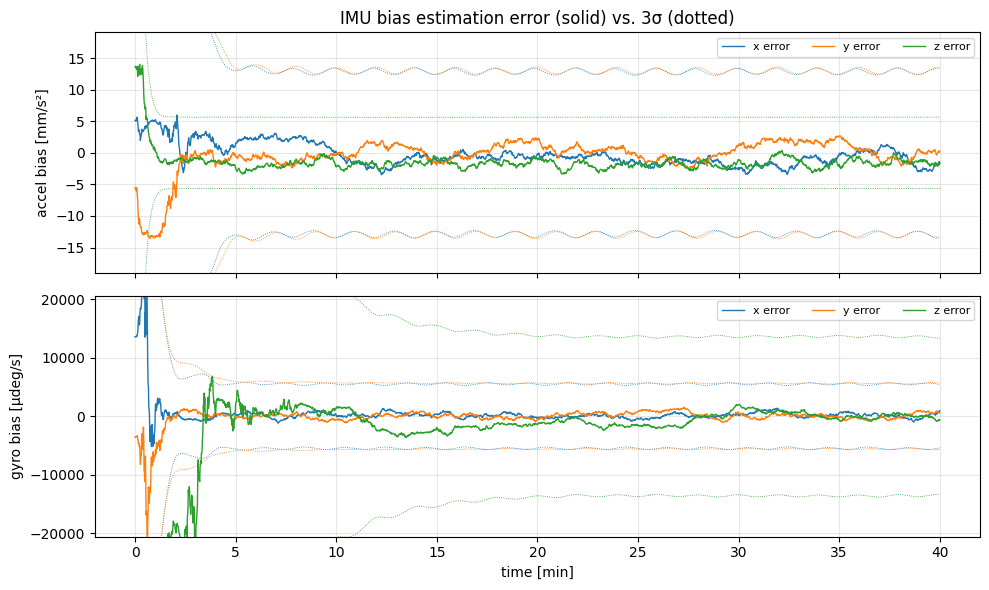

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax, (name, scale, unit) in zip(
        axes, [("accel_bias", 1e3, "mm/s²"), ("gyro_bias", 1e6 * 180 / np.pi, "µdeg/s")]):
    for c, col in zip("xyz", ["C0", "C1", "C2"]):
        ax.plot(t_min, on[f"{name}_err_{c}"] * scale, col, lw=1, label=f"{c} error")
        ax.plot(t_min, 3 * on[f"{name}_sigma_{c}"] * scale, col, lw=0.6, ls=":")
        ax.plot(t_min, -3 * on[f"{name}_sigma_{c}"] * scale, col, lw=0.6, ls=":")
    ax.set_ylabel(f"{name.replace('_', ' ')} [{unit}]"); ax.grid(alpha=0.3); ax.legend(ncol=3, fontsize=8)
    zoom_ylim(ax, *[on[f"{name}_err_{c}"] * scale for c in "xyz"],
              *[3 * on[f"{name}_sigma_{c}"] * scale for c in "xyz"])
axes[-1].set_xlabel("time [min]")
axes[0].set_title("IMU bias estimation error (solid) vs. 3σ (dotted)")
plt.tight_layout(); plt.show()

## 4. Attitude estimation

The attitude error (nav-frame rotation vector) and its 3σ envelope. Attitude observability comes from the accelerometer sensing gravity plus rover motion.

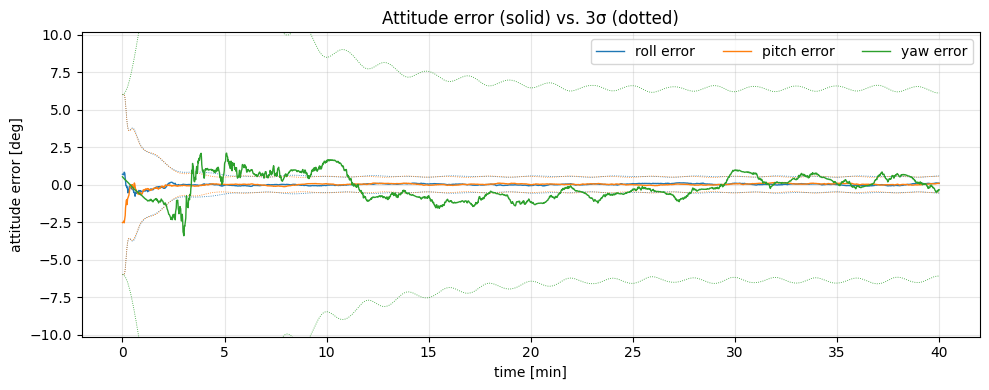

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for c, col, lbl in zip("xyz", ["C0", "C1", "C2"], ["roll", "pitch", "yaw"]):
    ax.plot(t_min, on[f"att_err_deg_{c}"], col, lw=1, label=f"{lbl} error")
    ax.plot(t_min, 3 * on[f"att_sigma_deg_{c}"], col, lw=0.6, ls=":")
    ax.plot(t_min, -3 * on[f"att_sigma_deg_{c}"], col, lw=0.6, ls=":")
ax.set_xlabel("time [min]"); ax.set_ylabel("attitude error [deg]")
ax.set_title("Attitude error (solid) vs. 3σ (dotted)"); ax.grid(alpha=0.3); ax.legend(ncol=3)
zoom_ylim(ax, *[on[f"att_err_deg_{c}"] for c in "xyz"], *[3 * on[f"att_sigma_deg_{c}"] for c in "xyz"])
plt.tight_layout(); plt.show()

## 5. Does the DEM constraint help?

Disabling the DEM altitude constraint frees the weakly-observable vertical channel; the Up error grows. The terrain height ties it down.

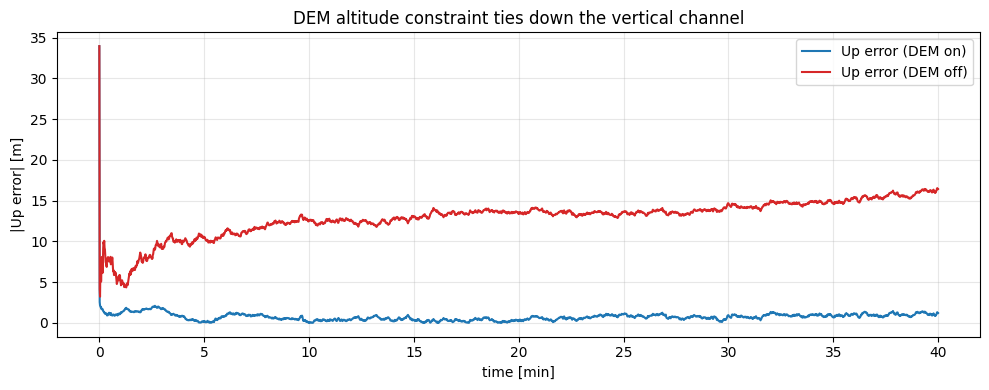

final |Up| error: DEM on 1.21 m, DEM off 16.42 m


In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_min, on["pos_err_z"].abs(), "C0", lw=1.5, label="Up error (DEM on)")
ax.plot(t_min, off["pos_err_z"].abs(), "C3", lw=1.5, label="Up error (DEM off)")
ax.set_xlabel("time [min]"); ax.set_ylabel("|Up error| [m]")
ax.set_title("DEM altitude constraint ties down the vertical channel")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
print(f"final |Up| error: DEM on {abs(on['pos_err_z'].iloc[-1]):.2f} m, "
      f"DEM off {abs(off['pos_err_z'].iloc[-1]):.2f} m")

## 6. Visible satellites and clock estimation

Number of LCRNS relays above the elevation mask, and the receiver-clock-bias error vs. 3σ.

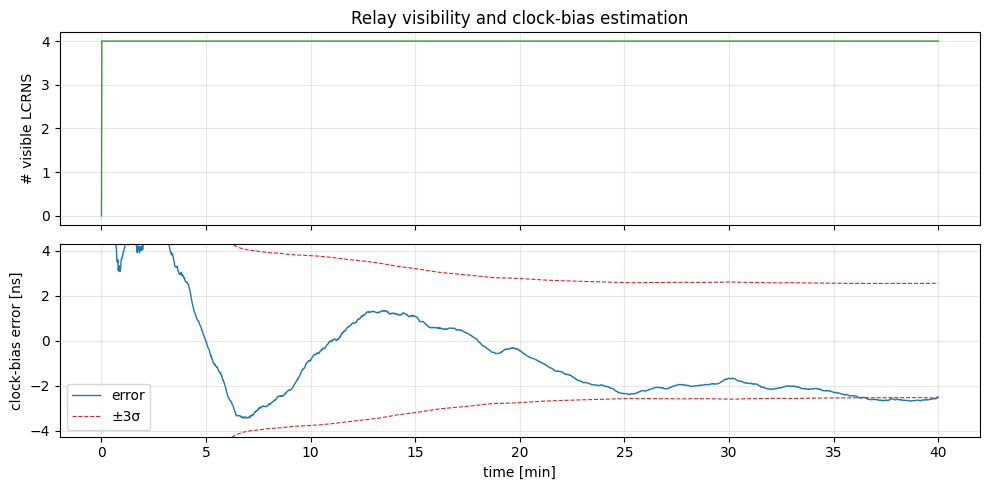

In [7]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
a1.plot(t_min, on["n_visible"], "C2", lw=1)
a1.set_ylabel("# visible LCRNS"); a1.grid(alpha=0.3)
a1.set_title("Relay visibility and clock-bias estimation")
a2.plot(t_min, on["clock_bias_err"] * 1e9, "C0", lw=1, label="error")
a2.plot(t_min, 3 * on["clock_bias_sigma"] * 1e9, "C3--", lw=0.8, label="±3σ")
a2.plot(t_min, -3 * on["clock_bias_sigma"] * 1e9, "C3--", lw=0.8)
a2.set_ylabel("clock-bias error [ns]"); a2.set_xlabel("time [min]"); a2.grid(alpha=0.3); a2.legend()
zoom_ylim(a2, on["clock_bias_err"] * 1e9, 3 * on["clock_bias_sigma"] * 1e9)
plt.tight_layout(); plt.show()

## Summary

A `SurfaceRoverNavApp` hosted on a thin `Rover` agent fuses IMU + LCRNS + a DEM altitude constraint in an error-state strapdown-INS EKF, estimating the IMU biases online. The scenario is fully described in `configs/surface_rover_nav.yaml`: a `LunarNavConstellation` agent stands in for all five relay satellites (one config entry, each a self-propagating orbit) and the rover sources their truth states from it; the `World` supplies the terrain, gravity, and ENU frame. Disabling the DEM constraint inflates the vertical error, showing how terrain height aids the weakly-observable Up channel.